In [3]:
print("ipykernel is installed!")

ipykernel is nstalled!


# k-means算法

d:\GitHub\Fanghui-Lang\mechine learning2024\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster centers:
[[3.25 2.5 ]
 [1.   1.  ]]
Labels:
[1 0 1 0 0 0]


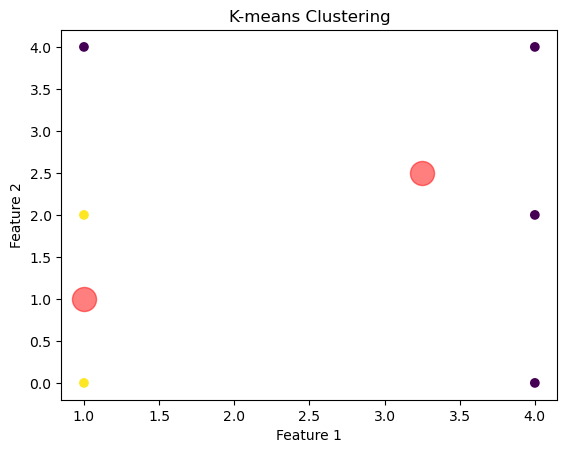

In [4]:
from sklearn.cluster import KMeans  
import numpy as np  
import matplotlib.pyplot as plt  
  
# 假设我们有一些二维数据  
data = np.array([[1, 2], [1, 4], [1, 0], [4, 2], [4, 4], [4, 0]])  
  
# 设置聚类数K  
K = 2  
  
# 初始化KMeans对象  
kmeans = KMeans(n_clusters=K, random_state=0)  
  
# 对数据进行拟合和预测  
kmeans.fit(data)  
labels = kmeans.predict(data)  
centroids = kmeans.cluster_centers_  
  
# 打印聚类中心和标签  
print("Cluster centers:")  
print(centroids)  
print("Labels:")  
print(labels)  
 
# 可视化结果  
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis')  
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=300, alpha=0.5)  
plt.title('K-means Clustering')  
plt.xlabel('Feature 1')  
plt.ylabel('Feature 2')  
plt.show()


# KNN算法

y_pred [0 2 2 1 0 2 1 2 2 2 1 2 1 1 0 0 0 1 0 1 1 1 1 2 1 1 0 1 0 1 1 1 0 0 0 0 2
 1]
y_test [0 1 1 1 0 1 2 2 2 2 2 2 1 1 0 0 0 1 0 1 2 1 2 1 2 1 0 2 0 1 2 2 0 0 0 0 2
 1]
score on train set 0.8482142857142857
score on test set 0.6842105263157895
accuracy score 0.6842105263157895


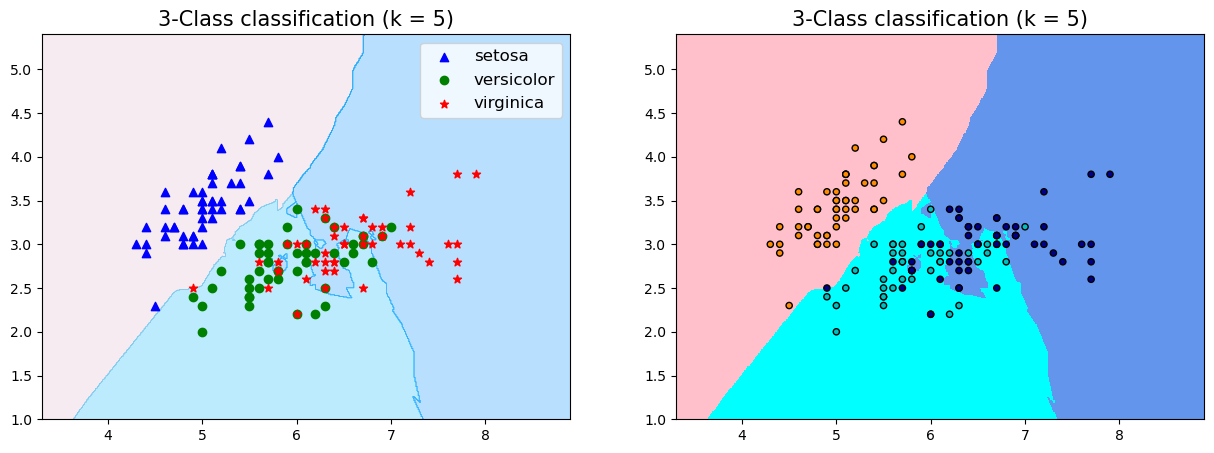

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
#导入iris数据
from sklearn.datasets import load_iris
iris = load_iris()
X=iris.data[:,:2] #只取前两列
y=iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,random_state=42) #划分数据，random_state固定划分方式
#导入模型
from sklearn.neighbors import KNeighborsClassifier 
#训练模型
n_neighbors = 5
knn = KNeighborsClassifier(n_neighbors=n_neighbors)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
#查看各项得分
print("y_pred",y_pred)
print("y_test",y_test)
print("score on train set", knn.score(X_train, y_train))
print("score on test set", knn.score(X_test, y_test))
print("accuracy score", accuracy_score(y_test, y_pred))

# 可视化

# 自定义colormap
def colormap():
    return mpl.colors.LinearSegmentedColormap.from_list('cmap', ['#FFC0CB','#00BFFF', '#1E90FF'], 256)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
axes=[x_min, x_max, y_min, y_max]
xp=np.linspace(axes[0], axes[1], 500) #均匀500的横坐标
yp=np.linspace(axes[2], axes[3],500) #均匀500个纵坐标
xx, yy=np.meshgrid(xp, yp) #生成500X500网格点
xy=np.c_[xx.ravel(), yy.ravel()] #按行拼接，规范成坐标点的格式
y_pred = knn.predict(xy).reshape(xx.shape) #训练之后平铺

# 可视化方法一
plt.figure(figsize=(15,5),dpi=100)
plt.subplot(1,2,1)
plt.contourf(xx, yy, y_pred, alpha=0.3, cmap=colormap())
#画三种类型的点
p1=plt.scatter(X[y==0,0], X[y==0, 1], color='blue',marker='^')
p2=plt.scatter(X[y==1,0], X[y==1, 1], color='green', marker='o')
p3=plt.scatter(X[y==2,0], X[y==2, 1], color='red',marker='*')
#设置注释
plt.legend([p1, p2, p3], iris['target_names'], loc='upper right',fontsize='large')
#设置标题
plt.title(f"3-Class classification (k = {n_neighbors})", fontdict={'fontsize':15} )

# 可视化方法二
plt.subplot(1,2,2)
cmap_light = ListedColormap(['pink', 'cyan', 'cornflowerblue'])
cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])
plt.pcolormesh(xx, yy, y_pred, cmap=cmap_light)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
                edgecolor='k', s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title(f"3-Class classification (k = {n_neighbors})" ,fontdict={'fontsize':15})
plt.show()
